--- DISTRIBUCIÓN TRAS UNDERSAMPLING ---
label
0    90
1    90
2    90
Name: count, dtype: int64

Calculando importancia con ReliefF (esto puede tardar unos segundos)...


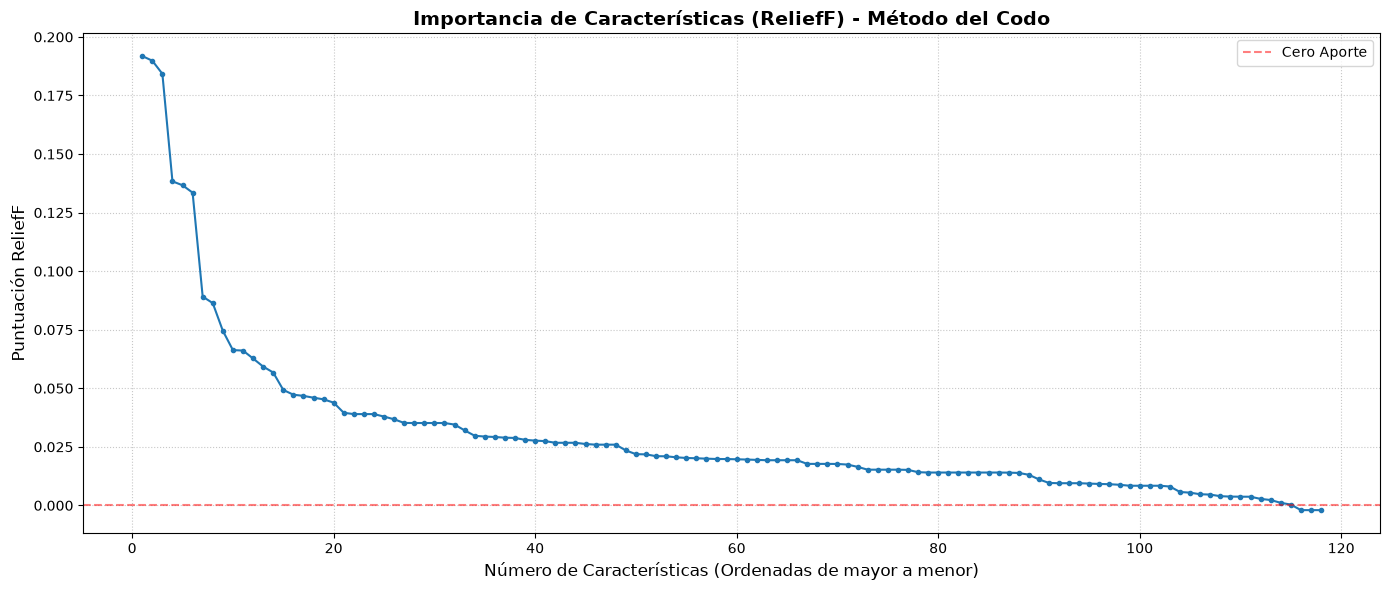


--- TOP 30 CARACTERÍSTICAS SEGÚN RELIEF ---


,Feature,Score
19,EDA_SCL_max,0.191845
16,EDA_SCL_mean,0.189847
18,EDA_SCL_min,0.184265
55,EDA_SCL_C_max,0.138345
52,EDA_SCL_C_mean,0.136683
54,EDA_SCL_C_min,0.133518
95,ECG_bpm,0.089145
96,ECG_ibi,0.086363
108,Resp_C_rate,0.074564
111,Resp_C_Exhal_mean,0.066299


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.under_sampling import RandomUnderSampler
from skrebate import ReliefF

# 1. Carga de datos
df = pd.read_csv("../anxietyFB-main/data/may14_feats4.csv")
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# 2. Separar características (X), objetivo (y) y grupos (subject)
X = df.drop(columns=['label', 'subject'])
y = df['label']
groups = df['subject'] # Vital conservarlo para el StratifiedGroupKFold posterior

# 3. Undersampling (Igualar clases)
# Añadimos 'subject' a X temporalmente para no perder a qué paciente pertenece cada fila tras el recorte
X_temp = X.copy()
X_temp['subject'] = groups

rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_temp, y)

# Separamos el 'subject' del dataset ya balanceado
groups_res = X_res['subject']
X_res = X_res.drop(columns=['subject'])

print("--- DISTRIBUCIÓN TRAS UNDERSAMPLING ---")
print(y_res.value_counts())

# 4. Escalar los datos (ReliefF es sensible a las escalas)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)

# 5. Aplicar ReliefF
print("\nCalculando importancia con ReliefF (esto puede tardar unos segundos)...")
# Usamos n_neighbors=20 (estándar para datasets medianos)
fs = ReliefF(n_features_to_select=X_res_scaled.shape[1], n_neighbors=20, n_jobs=-1)
fs.fit(X_res_scaled, y_res.values)

# Crear un DataFrame ordenado con los resultados
relief_scores = pd.DataFrame({
    'Feature': X_res.columns,
    'Score': fs.feature_importances_
}).sort_values(by='Score', ascending=False)

# 6. Visualización para encontrar el "Codo" (Optimal Number of Features)
plt.figure(figsize=(14, 6))
plt.plot(range(1, len(relief_scores) + 1), relief_scores['Score'], marker='.', linestyle='-')
plt.title('Importancia de Características (ReliefF) - Método del Codo', fontweight='bold', fontsize=14)
plt.xlabel('Número de Características (Ordenadas de mayor a menor)', fontsize=12)
plt.ylabel('Puntuación ReliefF', fontsize=12)

# Líneas guía visuales
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Cero Aporte')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# Mostrar el Top 30 para la tesis
print("\n--- TOP 30 CARACTERÍSTICAS SEGÚN RELIEF ---")
relief_scores.head(30)

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV, cross_val_predict
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
from sklearn.preprocessing import label_binarize

# 1. Seleccionar las 18 mejores características según ReliefF
top_18_features = relief_scores['Feature'].head(18).tolist()
X_selected = X_res[top_18_features]

print(f"--- SELECCIÓN DE CARACTERÍSTICAS ---")
print(f"Utilizando las 18 mejores variables: \n{top_18_features}\n")

# 2. Configurar StratifiedGroupKFold (La instrucción del tutor)
# Asegura que un paciente (subject) esté en Train o en Test, pero nunca en ambos
cv_sgkf = StratifiedGroupKFold(n_splits=5)

# 3. Configurar el Random Forest y la grilla de hiperparámetros
rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')

param_grid = {
    'n_estimators': [50, 100, 200],         # Cantidad de árboles
    'max_depth': [None, 10, 20],            # Profundidad máxima del árbol
    'min_samples_split': [2, 5, 10],        # Muestras mínimas para dividir un nodo
    'min_samples_leaf': [1, 2, 4]           # Muestras mínimas en una hoja final
}

# 4. Búsqueda de Hiperparámetros (GridSearchCV)
print("Buscando los mejores hiperparámetros (esto puede tomar un par de minutos)...")
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=cv_sgkf,
    scoring='f1_weighted', # Optimizamos buscando el mejor F1-Score
    n_jobs=-1,
    verbose=1
)

# ¡IMPORTANTE! Pasamos groups_res para que el StratifiedGroupKFold funcione
grid_search.fit(X_selected, y_res, groups=groups_res)

# 5. Resultados del mejor modelo
best_rf = grid_search.best_estimator_

print("\n--- MEJORES HIPERPARÁMETROS ENCONTRADOS ---")
for param, value in grid_search.best_params_.items():
    print(f" - {param}: {value}")

print(f"\nF1-Score (Weighted) Promedio en Validación Cruzada: {grid_search.best_score_:.4f}")

# 6. Evaluación detallada con el mejor modelo (Reporte Final)
print("\n--- REPORTE DE CLASIFICACIÓN FINAL (BEST MODEL) ---")
# Generamos predicciones cruzadas respetando los grupos
y_pred = cross_val_predict(best_rf, X_selected, y_res, cv=cv_sgkf, groups=groups_res)
y_prob = cross_val_predict(best_rf, X_selected, y_res, cv=cv_sgkf, groups=groups_res, method='predict_proba')

print(classification_report(y_res, y_pred))

# Cálculo de AUC Multiclase (One-vs-Rest)
y_res_bin = label_binarize(y_res, classes=[0, 1, 2])
auc_score = roc_auc_score(y_res_bin, y_prob, average='weighted', multi_class='ovr')
print(f"AUC (One-vs-Rest Ponderado): {auc_score:.4f}")
print(f"Accuracy Global: {accuracy_score(y_res, y_pred):.4f}")

--- SELECCIÓN DE CARACTERÍSTICAS ---
Utilizando las 18 mejores variables: 
['EDA_SCL_max', 'EDA_SCL_mean', 'EDA_SCL_min', 'EDA_SCL_C_max', 'EDA_SCL_C_mean', 'EDA_SCL_C_min', 'ECG_bpm', 'ECG_ibi', 'Resp_C_rate', 'Resp_C_Exhal_mean', 'ECG_pnn20', 'Resp_C_Inhal_std', 'net_acc_max', 'Resp_C_Exhal_std', 'Resp_C_Inhal_mean', 'ECG_std', 'TEMP_max', 'TEMP_mean']

Buscando los mejores hiperparámetros (esto puede tomar un par de minutos)...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

--- MEJORES HIPERPARÁMETROS ENCONTRADOS ---
 - max_depth: None
 - min_samples_leaf: 4
 - min_samples_split: 10
 - n_estimators: 200

F1-Score (Weighted) Promedio en Validación Cruzada: 0.8692

--- REPORTE DE CLASIFICACIÓN FINAL (BEST MODEL) ---
              precision    recall  f1-score   support

           0       0.78      0.94      0.85        90
           1       0.93      0.69      0.79        90
           2       0.95      0.99      0.97        90

    accuracy                           

Selección de Características (ReliefF a 18 variables): Al reducir de 121 a 18 características, eliminamos la redundancia y el ruido colineal. ReliefF fue elegido por su capacidad matemática para evaluar interacciones complejas entre variables y distinguir entre instancias vecinas de distintas clases.

Robustez Clínica (StratifiedGroupKFold): Justifica el cambio del StratifiedKFold normal al GroupKFold como una medida vital para evaluar la generalización clínica. Esto garantiza que el modelo evalúa su rendimiento prediciendo datos de sujetos completamente nuevos, evitando el sesgo de memorización del ritmo cardíaco base de un paciente específico.

Optimización (GridSearchCV): En lugar de usar valores por defecto, se barrió exhaustivamente una matriz de combinaciones de hiperparámetros para encontrar la configuración que maximiza estrictamente el F1-Score ponderado, dejando listo tu algoritmo campeón para la etapa final donde lo estresaremos contra los modelos Fundacionales Tabulares (Transformers).

In [5]:
import time
# Importamos la alternativa abierta mencionada en el paper
from tabicl import TabICLClassifier 
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import label_binarize

print("--- INICIANDO MODELADO CON TRANSFORMER TABULAR (TabICL) ---")

# Inicialización del modelo zero-shot, sin necesidad de tokens
tabicl_model = TabICLClassifier()

print("Realizando inferencia In-Context Learning con TabICL (esto tomará unos segundos)...")
start_time = time.time()

# Generación de predicciones cruzadas respetando los grupos (Data Leakage Prevention)
y_pred_tabicl = cross_val_predict(tabicl_model, X_selected, y_res, cv=cv_sgkf, groups=groups_res)

# Probabilidades para el cálculo del AUC
y_prob_tabicl = cross_val_predict(tabicl_model, X_selected, y_res, cv=cv_sgkf, groups=groups_res, method='predict_proba')

end_time = time.time()
print(f"\nInferencia completada en {end_time - start_time:.2f} segundos.")

print("\n--- REPORTE DE CLASIFICACIÓN (TabICL - BASELINE) ---")
print(classification_report(y_res, y_pred_tabicl))

acc_tabicl = accuracy_score(y_res, y_pred_tabicl)
print(f"Accuracy Global: {acc_tabicl:.4f}")

y_res_bin = label_binarize(y_res, classes=[0, 1, 2])
auc_tabicl = roc_auc_score(y_res_bin, y_prob_tabicl, average='weighted', multi_class='ovr')
print(f"AUC (One-vs-Rest Ponderado): {auc_tabicl:.4f}")

--- INICIANDO MODELADO CON TRANSFORMER TABULAR (TabICL) ---
Realizando inferencia In-Context Learning con TabICL (esto tomará unos segundos)...
INFO: You are downloading 'tabicl-classifier-v2-20260212.ckpt', the latest best-performing version, used in our TabICLv2 paper.

Checkpoint 'tabicl-classifier-v2-20260212.ckpt' not cached.



c:\Users\estef\anaconda3\envs\Tesis\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\estef\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\estef\anaconda3\envs\Tesis\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses s


Inferencia completada en 32.14 segundos.

--- REPORTE DE CLASIFICACIÓN (TabICL - BASELINE) ---
              precision    recall  f1-score   support

           0       0.79      0.74      0.77        90
           1       0.80      0.78      0.79        90
           2       0.91      0.99      0.95        90

    accuracy                           0.84       270
   macro avg       0.83      0.84      0.83       270
weighted avg       0.83      0.84      0.83       270

Accuracy Global: 0.8370
AUC (One-vs-Rest Ponderado): 0.9493
